In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [6]:
df.shape

(3556, 19)

In [7]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,smart world orchard,sector 61,1.41,12250.0,2.0,2.0,2,2.0,Under Construction,Situated in prime location of sector 61 on gol...,1150.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0
1,flat,dlf the primus,sector 82a,2.85,10936.0,4.0,4.0,3+,2.0,New Property,A north facing 4 bhk resale flat is available ...,2179.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0
2,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,2.0,2.0,2,14.0,Relatively New,"Club house, mini theater, squash court, swimmi...",915.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,house,independent,sector 7,1.20,11194.0,2.0,4.0,2,3.0,Old Property,5bhk residential house for resale in jyoti par...,1072.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,flat,hcbs sports ville,sohna road,0.27,4348.0,2.0,2.0,2,10.0,Relatively New,Raw flat as given by builder. Good location ne...,619.0,0.0,0.0,0.0,0.0,0.0,1.0,43.0


In [8]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [9]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 61,1.41,2.0,2.0,2,2.0,Under Construction,Situated in prime location of sector 61 on gol...,1150.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0
1,flat,sector 82a,2.85,4.0,4.0,3+,2.0,New Property,A north facing 4 bhk resale flat is available ...,2179.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0
2,flat,sector 102,0.95,2.0,2.0,2,14.0,Relatively New,"Club house, mini theater, squash court, swimmi...",915.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,house,sector 7,1.20,2.0,4.0,2,3.0,Old Property,5bhk residential house for resale in jyoti par...,1072.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,flat,sohna road,0.27,2.0,2.0,2,10.0,Relatively New,Raw flat as given by builder. Good location ne...,619.0,0.0,0.0,0.0,0.0,0.0,1.0,43.0


### luxury score

<Axes: ylabel='luxury_score'>

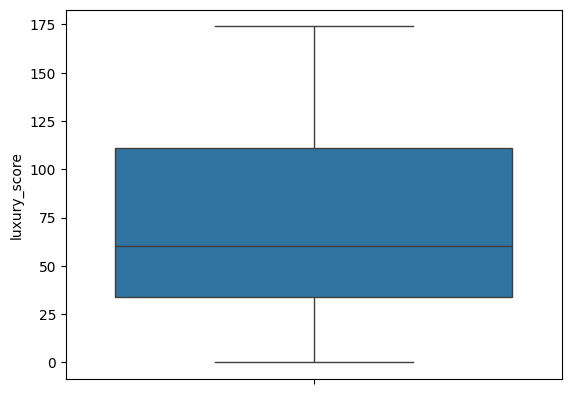

In [10]:
sns.boxplot(df['luxury_score'])

In [11]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None 

In [12]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [13]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 61,1.41,2.0,2.0,2,2.0,Under Construction,Situated in prime location of sector 61 on gol...,1150.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0,Medium
1,flat,sector 82a,2.85,4.0,4.0,3+,2.0,New Property,A north facing 4 bhk resale flat is available ...,2179.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0,High
2,flat,sector 102,0.95,2.0,2.0,2,14.0,Relatively New,"Club house, mini theater, squash court, swimmi...",915.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Low
3,house,sector 7,1.20,2.0,4.0,2,3.0,Old Property,5bhk residential house for resale in jyoti par...,1072.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Low
4,flat,sohna road,0.27,2.0,2.0,2,10.0,Relatively New,Raw flat as given by builder. Good location ne...,619.0,0.0,0.0,0.0,0.0,0.0,1.0,43.0,Low


### floorNum

<Axes: ylabel='floorNum'>

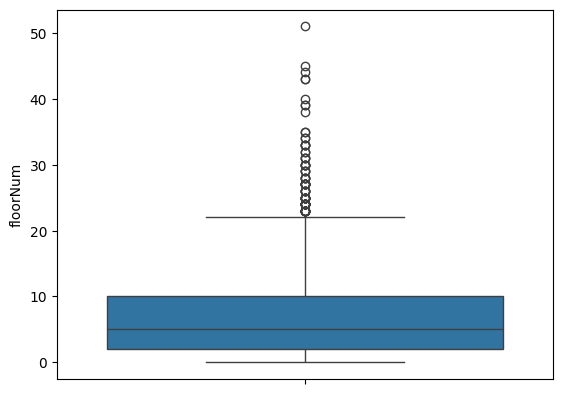

In [14]:
sns.boxplot(df['floorNum'])

In [15]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [16]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [17]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 61,1.41,2.0,2.0,2,2.0,Under Construction,Situated in prime location of sector 61 on gol...,1150.0,1.0,0.0,0.0,0.0,0.0,1.0,76.0,Medium,Low Floor
1,flat,sector 82a,2.85,4.0,4.0,3+,2.0,New Property,A north facing 4 bhk resale flat is available ...,2179.0,0.0,1.0,0.0,0.0,0.0,2.0,174.0,High,Low Floor
2,flat,sector 102,0.95,2.0,2.0,2,14.0,Relatively New,"Club house, mini theater, squash court, swimmi...",915.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Low,High Floor
3,house,sector 7,1.20,2.0,4.0,2,3.0,Old Property,5bhk residential house for resale in jyoti par...,1072.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,Low,Mid Floor
4,flat,sohna road,0.27,2.0,2.0,2,10.0,Relatively New,Raw flat as given by builder. Good location ne...,619.0,0.0,0.0,0.0,0.0,0.0,1.0,43.0,Low,Mid Floor


In [18]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [19]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 61,1.41,2.0,2.0,2,Under Construction,Situated in prime location of sector 61 on gol...,1150.0,1.0,0.0,0.0,0.0,0.0,1.0,Medium,Low Floor
1,flat,sector 82a,2.85,4.0,4.0,3+,New Property,A north facing 4 bhk resale flat is available ...,2179.0,0.0,1.0,0.0,0.0,0.0,2.0,High,Low Floor
2,flat,sector 102,0.95,2.0,2.0,2,Relatively New,"Club house, mini theater, squash court, swimmi...",915.0,0.0,0.0,0.0,0.0,0.0,1.0,Low,High Floor
3,house,sector 7,1.20,2.0,4.0,2,Old Property,5bhk residential house for resale in jyoti par...,1072.0,0.0,0.0,0.0,0.0,0.0,1.0,Low,Mid Floor
4,flat,sohna road,0.27,2.0,2.0,2,Relatively New,Raw flat as given by builder. Good location ne...,619.0,0.0,0.0,0.0,0.0,0.0,1.0,Low,Mid Floor


In [20]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37', 'sector 37c',
       'sector 37d', 'sector 38', 'sector 39', 'sector 4', 'sector 40',
       'sector 41', 'sector 43', 'sector 45', 'sector 46', 'sector 47',
       'sector 48', 'sector 49', 'sector 5', 'sector 50', 'sector 51',
       'sector 52', 'sect

In [21]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,71.0,2.0,2.0,2.0,4.0,2338.0,1150.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
1,0.0,96.0,4.0,4.0,4.0,1.0,413.0,2179.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0
2,0.0,6.0,2.0,2.0,2.0,3.0,901.0,915.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.0,81.0,2.0,4.0,2.0,2.0,332.0,1072.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
4,0.0,113.0,2.0,2.0,2.0,3.0,2095.0,619.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3551,0.0,100.0,3.0,3.0,4.0,3.0,2685.0,1780.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3552,1.0,24.0,4.0,4.0,0.0,2.0,2835.0,3000.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
3553,0.0,84.0,2.0,2.0,2.0,0.0,1443.0,1086.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
3554,0.0,87.0,2.0,2.0,4.0,3.0,2038.0,1200.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0


In [22]:
y_label

0       1.41
1       2.85
2       0.95
3       1.20
4       0.27
        ... 
3551    1.50
3552    3.00
3553    0.82
3554    1.54
3555    1.00
Name: price, Length: 3556, dtype: float64

### Technique 1 - Correlation Analysis

<Axes: >

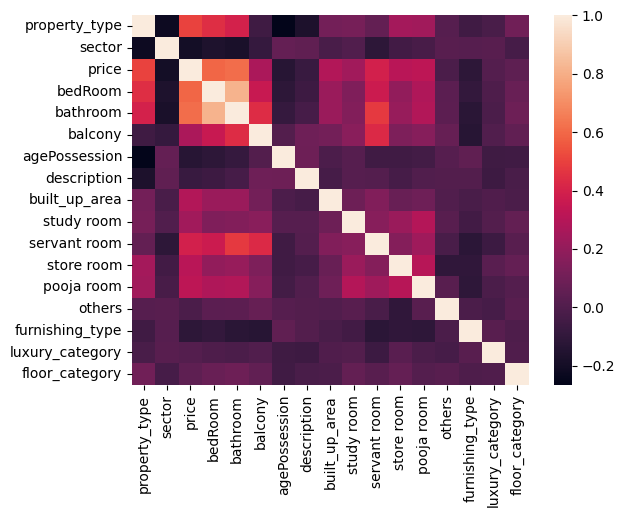

In [23]:
sns.heatmap(data_label_encoded.corr())

In [24]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.199406
1,price,1.000000
2,bedRoom,0.589584
3,bathroom,0.612374
4,balcony,0.271856
5,agePossession,-0.135767
6,description,-0.076334
7,built_up_area,0.290676
8,study room,0.240370
9,servant room,0.393879


### Technique 2 - Random Forest Feature Importance

In [25]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
7,built_up_area,0.619712
0,property_type,0.116872
1,sector,0.096375
6,description,0.034975
2,bedRoom,0.024607
3,bathroom,0.021990
9,servant room,0.021968
5,agePossession,0.011635
4,balcony,0.010825
13,furnishing_type,0.007811


### Technique 3 - Gradient Boosting Feature importances

In [26]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
7,built_up_area,0.665856
1,sector,0.103549
0,property_type,0.102751
2,bedRoom,0.040897
3,bathroom,0.035015
9,servant room,0.029555
6,description,0.006846
10,store room,0.006157
5,agePossession,0.003223
13,furnishing_type,0.002626


### Technique 4 - Permutation Importance

In [27]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
7,built_up_area,0.690648
0,property_type,0.209986
1,sector,0.149178
9,servant room,0.032142
2,bedRoom,0.022810
6,description,0.006475
3,bathroom,0.003993
5,agePossession,0.003619
8,study room,0.002887
15,floor_category,0.001458


### Technique 5 - LASSO

In [28]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
0,property_type,0.763866
3,bathroom,0.622900
2,bedRoom,0.406049
9,servant room,0.392799
7,built_up_area,0.373728
10,store room,0.252469
8,study room,0.221937
11,pooja room,0.128696
14,luxury_category,0.071847
4,balcony,0.064415


### Technique 6 - RFE

In [29]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor


# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
7,built_up_area,0.620737
0,property_type,0.115634
1,sector,0.099813
6,description,0.034505
2,bedRoom,0.026095
9,servant room,0.022261
3,bathroom,0.021975
5,agePossession,0.010918
4,balcony,0.010722
13,furnishing_type,0.007412


### Technique 7 - Linear Regression Weights

In [31]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature' : X_label.columns,
    'reg_coeffs' : lin_reg.coef_
}).sort_values(by = 'reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
0,property_type,0.768043
3,bathroom,0.620865
2,bedRoom,0.406119
9,servant room,0.395520
7,built_up_area,0.380581
10,store room,0.254973
8,study room,0.228559
11,pooja room,0.132254
14,luxury_category,0.081116
4,balcony,0.072032


### Technique 8 - SHAP

In [32]:
!pip install shap

   ---------------------------------------- 0.0/544.3 kB ? eta -:--:--
   ------------------- -------------------- 262.1/544.3 kB ? eta -:--:--
   ---------------------------------------- 544.3/544.3 kB 1.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.7 MB 2.4 MB/s eta 0:00:01
   ------------------- -------------------- 1.3/2.7 MB 2.3 MB/s eta 0:00:01
   -------------------------- ------------- 1.8/2.7 MB 2.3 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.7 MB 2.2 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.7 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 2.0 MB/s  0:00:01
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 2.8 MB/s eta 0:00:14
   - ------------------------------------

In [33]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


array([[-0.19425189,  0.53289894, -0.04888215, ..., -0.01038393,
        -0.00331458, -0.02932901],
       [-0.41146019, -0.35079055,  0.04458934, ...,  0.27109631,
         0.06004828, -0.0104034 ],
       [-0.18935426,  0.03426918, -0.04577211, ..., -0.01115915,
        -0.00617133,  0.03277413],
       ...,
       [-0.17383501, -0.03930264, -0.03435045, ..., -0.01128899,
        -0.01030804, -0.0239582 ],
       [-0.17358829,  0.18917243, -0.03865454, ..., -0.0073509 ,
         0.00241488,  0.0391651 ],
       [-0.2028678 , -0.07989273, -0.05089842, ...,  0.0115522 ,
        -0.0042257 , -0.01343349]])

In [34]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
7,built_up_area,1.245894
0,property_type,0.507709
1,sector,0.378891
3,bathroom,0.108968
9,servant room,0.095942
2,bedRoom,0.058548
6,description,0.045175
4,balcony,0.038324
13,furnishing_type,0.024488
15,floor_category,0.023678


In [35]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [36]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
sector,-0.199406,0.096375,0.103549,0.149178,-0.126227,0.099813,-0.133728,0.378891
bedRoom,0.589584,0.024607,0.040897,0.022810,0.406049,0.026095,0.406119,0.058548
bathroom,0.612374,0.021990,0.035015,0.003993,0.622900,0.021975,0.620865,0.108968
balcony,0.271856,0.010825,0.000999,-0.000411,0.064415,0.010722,0.072032,0.038324
agePossession,-0.135767,0.011635,0.003223,0.003619,-0.013648,0.010918,-0.020758,0.021761
description,-0.076334,0.034975,0.006846,0.006475,-0.012454,0.034505,-0.020908,0.045175
built_up_area,0.290676,0.619712,0.665856,0.690648,0.373728,0.620737,0.380581,1.245894
study room,0.240370,0.005913,0.000706,0.002887,0.221937,0.005531,0.228559,0.014403
servant room,0.393879,0.021968,0.029555,0.032142,0.392799,0.022261,0.395520,0.095942


In [37]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [38]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.698990
sector             0.136207
servant room       0.032766
bedRoom            0.031157
bathroom           0.028994
description        0.022966
agePossession      0.008685
balcony            0.008654
furnishing_type    0.006448
store room         0.006090
floor_category     0.004958
study room         0.004750
luxury_category    0.004421
pooja room         0.002961
others             0.001952
dtype: float64

In [39]:
# to drop pooja room, study room, others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,71.0,2.0,2.0,2.0,4.0,2338.0,1150.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
1,0.0,96.0,4.0,4.0,4.0,1.0,413.0,2179.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0
2,0.0,6.0,2.0,2.0,2.0,3.0,901.0,915.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.0,81.0,2.0,4.0,2.0,2.0,332.0,1072.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
4,0.0,113.0,2.0,2.0,2.0,3.0,2095.0,619.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3551,0.0,100.0,3.0,3.0,4.0,3.0,2685.0,1780.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3552,1.0,24.0,4.0,4.0,0.0,2.0,2835.0,3000.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
3553,0.0,84.0,2.0,2.0,2.0,0.0,1443.0,1086.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
3554,0.0,87.0,2.0,2.0,4.0,3.0,2038.0,1200.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0


In [40]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [41]:
scores.mean()

0.7989489260156546

In [42]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [43]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [44]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,description,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,71.0,2.0,2.0,2.0,4.0,2338.0,1150.0,0.0,0.0,1.0,2.0,1.0,1.41
1,0.0,96.0,4.0,4.0,4.0,1.0,413.0,2179.0,1.0,0.0,2.0,0.0,1.0,2.85
2,0.0,6.0,2.0,2.0,2.0,3.0,901.0,915.0,0.0,0.0,1.0,1.0,0.0,0.95
3,1.0,81.0,2.0,4.0,2.0,2.0,332.0,1072.0,0.0,0.0,1.0,1.0,2.0,1.20
4,0.0,113.0,2.0,2.0,2.0,3.0,2095.0,619.0,0.0,0.0,1.0,1.0,2.0,0.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3551,0.0,100.0,3.0,3.0,4.0,3.0,2685.0,1780.0,0.0,0.0,1.0,0.0,0.0,1.50
3552,1.0,24.0,4.0,4.0,0.0,2.0,2835.0,3000.0,0.0,0.0,1.0,1.0,1.0,3.00
3553,0.0,84.0,2.0,2.0,2.0,0.0,1443.0,1086.0,0.0,0.0,1.0,1.0,2.0,0.82
3554,0.0,87.0,2.0,2.0,4.0,3.0,2038.0,1200.0,0.0,0.0,1.0,2.0,0.0,1.54
